# Task 1: Build a Random Forest Classifier (Customer Churn)

This notebook demonstrates building a Random Forest Classifier to predict **Customer Churn**. It loads the actual dataset provided, pre-processes categorical fields, trains the model with hyperparameter tuning, and evaluates the performance.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

## 1. Data Loading and Preprocessing
We load `churn-bigml-80.csv`. We will drop identifiers like `State` and `Area code`, and convert boolean strings (`Yes`/`No`, `True`/`False`) into numeric values `1`/`0` for the model.

In [2]:
df = pd.read_csv('churn-bigml-80.csv')

# Map categorical columns to binary variables
df['International plan'] = df['International plan'].map({'Yes': 1, 'No': 0})
df['Voice mail plan'] = df['Voice mail plan'].map({'Yes': 1, 'No': 0})
df['Churn'] = df['Churn'].astype(int)

# Drop string identifiers (State) and categorical but numerical-like identifiers (Area code)
X = df.drop(['State', 'Area code', 'Churn'], axis=1)
y = df['Churn']

print(f"Dataset features shape: {X.shape}")
print("Target Class Distribution:")
print(y.value_counts())
X.head()

Dataset features shape: (2666, 17)
Target Class Distribution:
Churn
0    2278
1     388
Name: count, dtype: int64


,Account length,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls
0,128,0,1,25,265.1,110,45.07,197.4,99,16.78,244.7,91,11.01,10.0,3,2.70,1
1,107,0,1,26,161.6,123,27.47,195.5,103,16.62,254.4,103,11.45,13.7,3,3.70,1
2,137,0,0,0,243.4,114,41.38,121.2,110,10.30,162.6,104,7.32,12.2,5,3.29,0
3,84,1,0,0,299.4,71,50.90,61.9,88,5.26,196.9,89,8.86,6.6,7,1.78,2
4,75,1,0,0,166.7,113,28.34,148.3,122,12.61,186.9,121,8.41,10.1,3,2.73,3


## 2. Train-Test Split
We split the loaded data into training (80%) and testing (20%) sets.

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training samples: {X_train.shape[0]}")
print(f"Testing samples: {X_test.shape[0]}")

Training samples: 2132
Testing samples: 534


## 3. Model Initialization & Hyperparameter Tuning
We use `GridSearchCV` to test multiple combinations of hyperparameters (`n_estimators`, `max_depth`) to find the best performing model.

In [4]:
rf = RandomForestClassifier(random_state=42, class_weight='balanced')

param_grid = {
    'n_estimators': [50, 100, 150],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5]
}

grid_search = GridSearchCV(
    estimator=rf, 
    param_grid=param_grid, 
    cv=3, 
    n_jobs=-1, 
    scoring='f1_macro'
)

print("Tuning hyperparameters...")
grid_search.fit(X_train, y_train)

best_rf = grid_search.best_estimator_
print("Best Hyperparameters:", grid_search.best_params_)

Tuning hyperparameters...
Best Hyperparameters: {'max_depth': 20, 'min_samples_split': 5, 'n_estimators': 100}


## 4. Cross-Validation Evaluation

In [5]:
cv_scores = cross_val_score(best_rf, X, y, cv=5, scoring='f1_macro')
print("Cross-Validation F1 Scores:", np.round(cv_scores, 4))
print(f"Average F1 Score: {np.mean(cv_scores):.4f} (+/- {np.std(cv_scores):.4f})")

Cross-Validation F1 Scores: [0.8979 0.8601 0.9286 0.8502 0.9084]
Average F1 Score: 0.8890 (+/- 0.0296)


## 5. Test Set Evaluation & Classification Metrics

================ Classification Report ================
              precision    recall  f1-score   support

           0       0.95      1.00      0.97       456
           1       0.98      0.71      0.82        78

    accuracy                           0.96       534
   macro avg       0.97      0.85      0.90       534
weighted avg       0.96      0.96      0.95       534



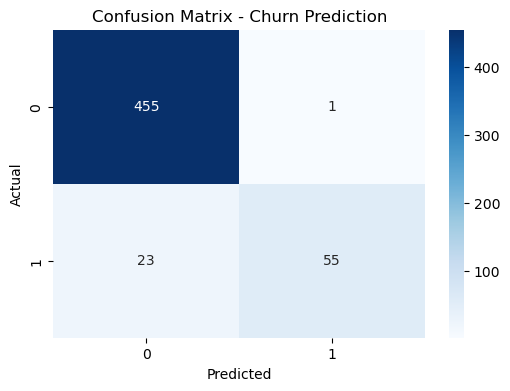

In [ ]:
y_pred = best_rf.predict(X_test)

print("Classification Report")
print(classification_report(y_test, y_pred))

plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - Churn Prediction")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## 6. Feature Importance Analysis

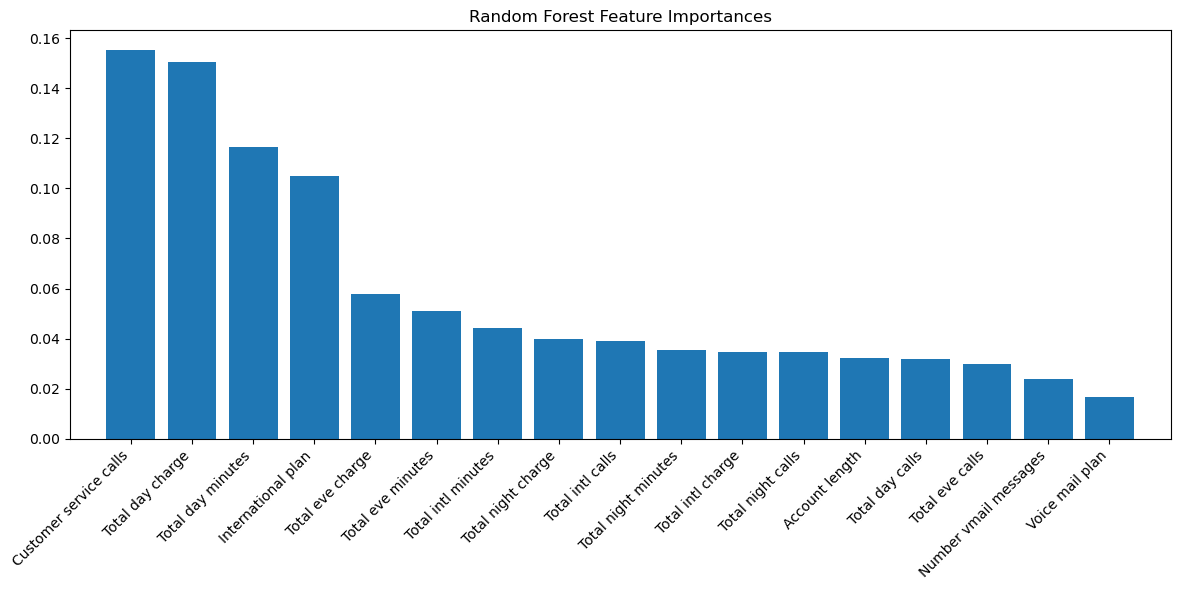

In [7]:
importances = best_rf.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(12, 6))
plt.title("Random Forest Feature Importances")
plt.bar(range(X.shape[1]), importances[indices], align="center")
plt.xticks(range(X.shape[1]), [X.columns[i] for i in indices], rotation=45, ha='right')
plt.xlim([-1, X.shape[1]])
plt.tight_layout()
plt.show()